___

# Machine Learning in Geosciences 
Department of Applied Geoinformatics and Carthography, Charles University

Lukas Brodsky lukas.brodsky@natur.cuni.cz

## Exercise: Building and Evaluating Ensemble Models

This notebook is dedicated to ensemble learning exercizes. 

**Objective**:
Understand and implement different ensemble learning techniques — Bagging, Boosting, and Stacking and compare their performance.

Tasks: 
1. Implement Bagging using `BaggingClassifier()` and compare the result with a weak classifier, e.g. `DecisionTreeClassifier()` using high variance (noisy moons) dataset. 

2. Implement Boosting using `GradientBoostingClassifier()` and compare result with a weak classifier `DecisionTreeClassifier()` on  a complex decision boundary (circles) dataset. 

3. Implement Stacking using `StackingClassifier()` based on `SVC()`, `DecisionTreeClassifier()` and `KNeighborsClassifier()` and `LogisticRegression()`. Compare the stacking result with single weak classifiers, e.g. `DecisionTreeClassifier()`.  

In [1]:
print('hi')

hi


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# ensmbles 
from sklearn.ensemble import BaggingClassifier, GradientBoostingClassifier, StackingClassifier
# base estimators 
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

### Dataset 1 - bagging

In [7]:
# Dataset 1 for BAGGING: High Variance (Noisy Moons)
X_bagging, y_bagging = make_moons(n_samples=1000, noise=0.4, random_state=42)
X_train_bag, X_test_bag, y_train_bag, y_test_bag = train_test_split(X_bagging, y_bagging, 
                                                                    test_size=0.2, random_state=42)

Text(0.5, 1.0, 'Dataset: High Variance')

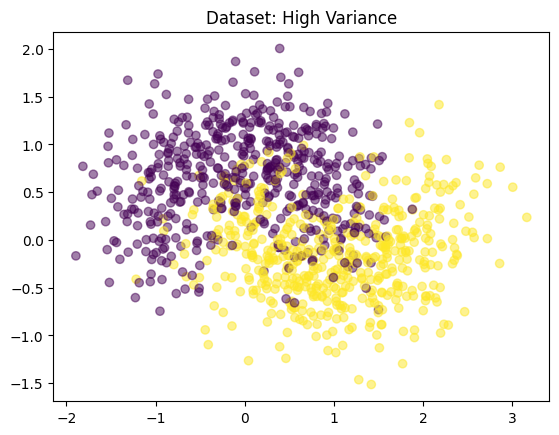

In [10]:
plt.scatter(X_bagging[:, 0], X_bagging[:, 1], c=y_bagging, cmap="viridis", alpha=0.5)
plt.title("Dataset: High Variance")

### Bagging classifier

**A Bagging classifier** is an ensemble meta-estimator that fits base classifiers each on random subsets of the original dataset and then aggregate their individual predictions (either by voting or by averaging) to form a final prediction. Such a meta-estimator can typically be used as a way to reduce the variance of a black-box estimator (e.g., a decision tree), by introducing randomization into its construction procedure and then making an ensemble out of it.

`
class sklearn.ensemble.BaggingClassifier(
    estimator=None, 
    n_estimators=10, 
    max_samples=1.0,
    max_features=1.0, 
    bootstrap=True,
    n_jobs=None
    )
`

In [11]:
# hyperparameters tunes number of estimators, sample size, and bootstrap settings.
bagging_params = {
    "n_estimators": [50, 100, 150, 200],
    "max_samples": [0.5, 0.8, 1.0]
}

In [12]:
# use GridSearchCV() on BaggingClassifier() with DecisionTreeClassifier()
# cv=10, return_train_score=True 
bagging_grid = GridSearchCV(
    BaggingClassifier(estimator=DecisionTreeClassifier(), random_state=42), 
    param_grid=bagging_params, 
    cv=10, 
    return_train_score=True 
) 

In [13]:
# search and fit 
bagging_grid.fit(X_train_bag, y_train_bag) 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BaggingClassi...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_samples': [0.5, 0.8, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also display

In [14]:
# best paramters are: estimator.best_params_
print("Best Parameters:", bagging_grid.best_params_) 

Best Parameters: {'max_samples': 0.5, 'n_estimators': 150}


In [15]:
# the best one is: estimator.best_estimator_
print("Best Estimator:", bagging_grid.best_estimator_)

Best Estimator: BaggingClassifier(estimator=DecisionTreeClassifier(), max_samples=0.5,
                  n_estimators=150, random_state=42)


#### Model evaluation

In [16]:
# training score: estimator.best_score_
BC_train_acc = bagging_grid.best_score_
BC_train_acc

np.float64(0.8450000000000001)

In [17]:
# prediction for testing 
bagging_pred = bagging_grid.best_estimator_.predict(X_test_bag) 

In [18]:
bagging_best = bagging_grid.best_estimator_

In [19]:
# accuracy: accuracy_score(y_test_bag, bagging_pred)
BC_test_acc = accuracy_score(y_test_bag, bagging_pred)


In [20]:
# print the accuracies
print(f"Training Accuracy: {BC_train_acc * 100:.2f}%")
print(f"Test Accuracy: {BC_test_acc * 100:.2f}%")

Training Accuracy: 84.50%
Test Accuracy: 84.50%


#### Plot decision boundary

In [21]:
# Ensemble Decision Boundary
def plot_ensmble_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    for model in model.estimators_:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)
        cs = plt.contourf(xx, yy, Z, alpha=0.1)

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", marker="o", alpha=0.3)
    plt.title(title)

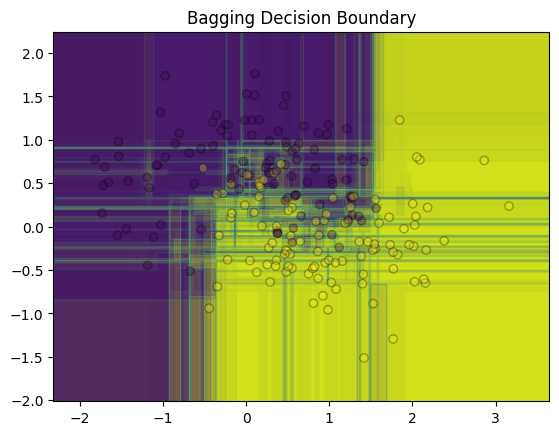

In [22]:
plot_ensmble_boundary(bagging_best, X_test_bag, y_test_bag, "Bagging Decision Boundary")

### Single model Decision Tree

In [23]:
# DT DecisionTreeClassifier()  
DT_clf = DecisionTreeClassifier(random_state=42) 

In [24]:
# fit the model 
DT_clf.fit(X_train_bag, y_train_bag)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [25]:
# training accuracy: accuracy_score()
DT_train_acc =  accuracy_score(y_train_bag, DT_clf.predict(X_train_bag))
DT_train_acc

1.0

In [26]:
# testing accuracy: accuracy_score()
DT_test_acc = accuracy_score(y_test_bag, DT_clf.predict(X_test_bag)) 
DT_test_acc

0.78

In [27]:
# Decision Boundary Plot
def plot_decision_boundary(model, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", marker="o", alpha=0.3)
    plt.contourf(xx, yy, Z, alpha=0.5)

    plt.title(title)

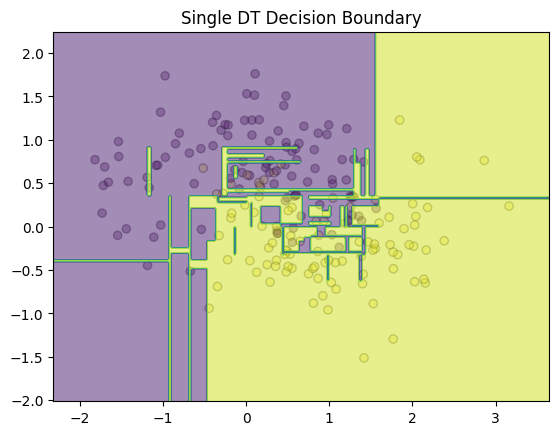

In [28]:
plot_decision_boundary(DT_clf, X_test_bag, y_test_bag, "Single DT Decision Boundary")

#### Models comparison (accuarcy)

In [29]:
print("\n===== Models Comparision =====")
print(f'Bagging training error: {round(BC_train_acc, 2)}')
print(f'Bagging testing  error: {round(BC_test_acc , 2)}')
print('---')
print(f'Decition Tree training: {round(DT_train_acc, 2)}')
print(f'Decition Tree training: {round(DT_test_acc, 2)}')


===== Models Comparision =====
Bagging training error: 0.85
Bagging testing  error: 0.84
---
Decition Tree training: 1.0
Decition Tree training: 0.78


### Does averaging weak learners reduces overfitting on noisy data? 

.

### Boosting classifier 

**Gradient Boosting** for classification builds an additive model in a forward stage-wise fashion; it allows for the optimization of arbitrary differentiable loss functions. In each stage n_classes_ regression trees are fit on the negative gradient of the loss function, e.g. binary or multiclass log loss. 

`
class sklearn.ensemble.GradientBoostingClassifier(
    n_estimators=100, 
    learning_rate=0.1, 
    max_depth=3
    )
`

where learning rate shrinks the contribution of each tree by learning_rate. There is a trade-off between learning_rate and n_estimators. Values must be in the range [0.0, inf).

### Dataset 2 - boosting 

In [30]:
# Dataset 2 for BOOSTING: Complex Decision Boundary (Circles)
X_boosting, y_boosting = make_circles(n_samples=1000, noise=0.2, factor=0.5, random_state=42)
X_train_boost, X_test_boost, y_train_boost, y_test_boost = train_test_split(X_boosting, y_boosting, test_size=0.2, random_state=42)

Text(0.5, 1.0, 'Dataset: Complex Decision Boundary')

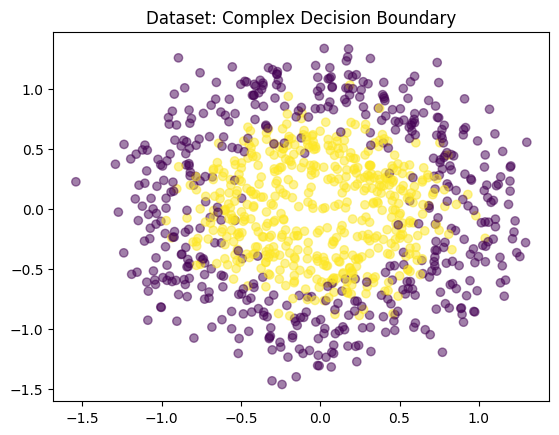

In [31]:
plt.scatter(X_boosting[:, 0], X_boosting[:, 1], c=y_boosting, cmap="viridis", alpha=0.5)
plt.title("Dataset: Complex Decision Boundary")

### Boosting classifier

In [32]:
# Boosting model
boosting_clf = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

In [33]:
# Boosting: optimizes tree depth, learning rate, and number of estimators
boosting_params = {
    "n_estimators": [50, 100, 200],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [2, 3, 4]
}

In [ ]:
# run GridSearchCV() on GradientBoostingClassifier 
# cv=5
boosting_grid = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=boosting_params,
    cv=5,
    return_train_score=True
)

In [44]:
# fit through grid search CV 
boosting_grid.fit(X_train_boost, y_train_boost) 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.1, ...], 'max_depth': [2, 3, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",6
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2

In [45]:
# the best one: boosting_estimator.best_estimator_
print("Best Parameters:", boosting_grid.best_params_) 

Best Parameters: {'learning_rate': 0.01, 'max_depth': 4, 'n_estimators': 200}


In [46]:
# training score: boosting_estimator.best_score_
Boost_train_acc = boosting_grid.best_score_
Boost_train_acc 

np.float64(0.8912860509482662)

In [47]:
# test the model 
boosting_pred = boosting_grid.best_estimator_.predict(X_test_boost) 

In [48]:
boosting_best = boosting_grid.best_estimator_

In [49]:
# testing acccuracy accuracy_score()
Boost_test_acc = accuracy_score(y_test_boost, boosting_pred) 

In [50]:
# print
print(f"Boosting Training Accuracy: {Boost_train_acc * 100:.2f}%")
print(f"Boosting Test Accuracy: {Boost_test_acc * 100:.2f}%")

Boosting Training Accuracy: 89.13%
Boosting Test Accuracy: 83.00%


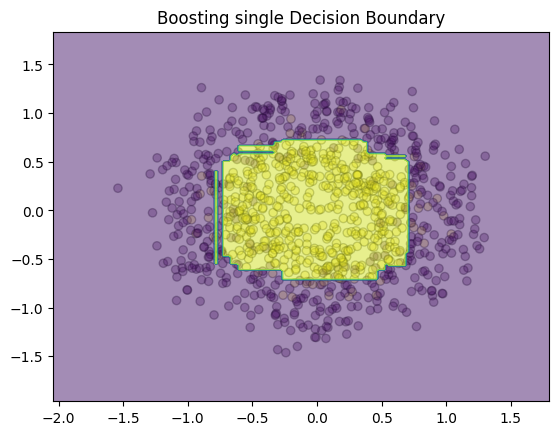

In [51]:
plot_decision_boundary(boosting_best, X_boosting, y_boosting, "Boosting single Decision Boundary")

In [53]:
# Function to Plot Decision Boundaries at Different Stages
def plot_decision_boundaries_ensemble(model, X, y, stages=[1, 5, 50, 100], 
                                      title="Gradient Boosting Evolution"):
    h = 0.02  # Step size in meshgrid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    fig, axes = plt.subplots(1, len(stages), figsize=(15, 4))
    for ax, stage in zip(axes, stages):
        # Partial predictions using first `stage` trees
        stage_model = GradientBoostingClassifier(n_estimators=stage, learning_rate=0.1, random_state=42)
        stage_model.fit(X, y)
        Z = stage_model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        # Plot decision boundary
        ax.contourf(xx, yy, Z, alpha=0.5)
        ax.set_title(f"{stage} Model(s)")
        ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", marker="o", alpha=0.1)
    plt.suptitle(title)
    plt.show()

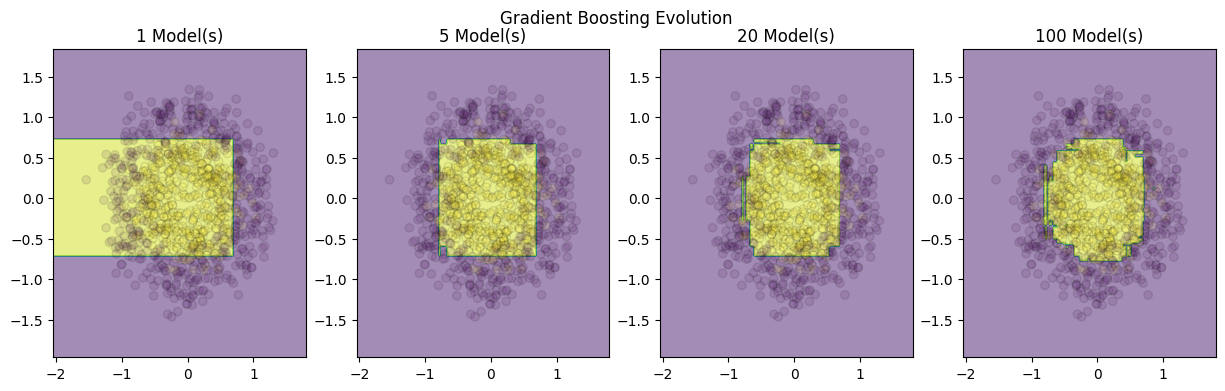

In [54]:
plot_decision_boundaries_ensemble(boosting_best, X_boosting, y_boosting, stages=[1, 5, 20, 100], 
                                  title="Gradient Boosting Evolution")

### Weaker classifier

In [55]:
# DecisionTreeClassifier()
DT_clf_boost = DecisionTreeClassifier(random_state=42) 

In [56]:
# fit model
DT_clf_boost.fit(X_train_boost, y_train_boost) 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [57]:
# training accuracy
DT_train_acc = accuracy_score(y_train_boost, DT_clf_boost.predict(X_train_boost))
DT_train_acc 

1.0

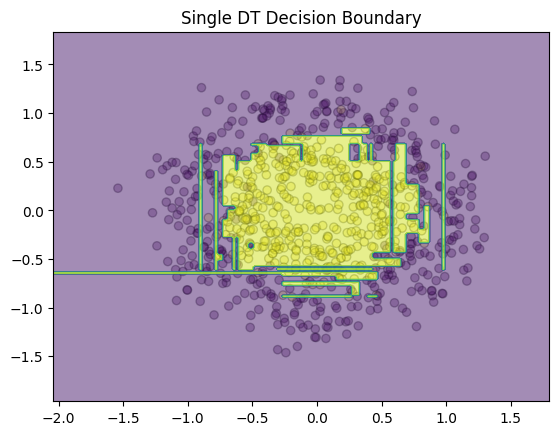

In [58]:
plot_decision_boundary(DT_clf_boost, X_train_boost, y_train_boost, "Single DT Decision Boundary")

In [59]:
print("\n===== Models Comparision =====")
print(f'Boosting training error: {round(Boost_train_acc, 2)}')
print(f'Boosting testing  error: {round(Boost_test_acc, 2)}')
print('---')
print(f'Decition Tree training: {round(DT_train_acc, 2)}')
print(f'Decition Tree training: {round(DT_test_acc, 2)}')


===== Models Comparision =====
Boosting training error: 0.89
Boosting testing  error: 0.83
---
Decition Tree training: 1.0
Decition Tree training: 0.78


### Does boosting improves weak model errors in overlapping, complex patterns? 

.

### Stacking 

**Stack of estimators with a final classifier** consists in stacking the output of individual estimator and use a classifier to compute the final prediction. Stacking allows to use the strength of each individual estimator by using their output as input of a final estimator.

`
class sklearn.ensemble.StackingClassifier(
    estimators,
    final_estimator
    )
`

wehere `estimators` are base estimators, 
and `final_estimator` is a classifier which will be used to combine the base estimators. The default classifier is a LogisticRegression.

### Dataset 3 - stacking

In [60]:
# Dataset 3 for STACKING: Diverse Model Mistakes (Classification)
X_stacking, y_stacking = make_classification(n_samples=1000, n_features=10, n_informative=3, class_sep=0.5, 
                                             n_redundant=2, n_clusters_per_class=2, random_state=42)

X_train_stack, X_test_stack, y_train_stack, y_test_stack = train_test_split(X_stacking, y_stacking, 
                                                                            test_size=0.2, random_state=42)

In [61]:
# use SVM, DT, and KNN 
stacking_estimators = [
    ('svm', SVC(probability=True, kernel='rbf', random_state=42)),
    ('dt', DecisionTreeClassifier(random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

In [62]:
# stacking: fine-tunes Logistic Regression used as the meta-classifier. 
stacking_params = {
    "final_estimator__C": [0.1, 1, 10]  # regularization strength for Logistic Regression
}

In [63]:
# run GridSearchCV() on StackingClassifier() using e.g. cv=10 
stacking_grid = GridSearchCV(
    StackingClassifier(estimators=stacking_estimators, final_estimator=LogisticRegression(random_state=42)),
    param_grid=stacking_params,
    cv=10,
    return_train_score=True
) 

In [64]:
# search and fit 
stacking_grid.fit(X_train_stack, y_train_stack) 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",StackingClass...dom_state=42))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'final_estimator__C': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [65]:
stacking_grid 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",StackingClass...dom_state=42))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'final_estimator__C': [0.1, 1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",10
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and cand

In [66]:
# the best one is: .best_estimator_
stacking_best = stacking_grid.best_estimator_
print("Best Parameters:", stacking_grid.best_params_) 

Best Parameters: {'final_estimator__C': 10}


In [67]:
# training score: .best_score_
Stack_train_acc = stacking_grid.best_score_
Stack_train_acc 

np.float64(0.81875)

In [68]:
# testing: 
stacking_pred = stacking_best.predict(X_test_stack)
Stack_test_acc = accuracy_score(y_test_stack, stacking_pred) 

In [69]:
# testing accuracy
Stack_test_acc = accuracy_score(y_test_stack, stacking_pred) 

In [70]:
# print
print(f"Stacking Training Accuracy: {Stack_train_acc * 100:.2f}%")
print(f"Stacking Test Accuracy: {Stack_test_acc * 100:.2f}%")

Stacking Training Accuracy: 81.88%
Stacking Test Accuracy: 80.50%


### Weaker classifiers

In [71]:
# SVM: SVC(probability=True, kernel='rbf', random_state=42) 

svc_clf_stack = SVC(probability=True, kernel='rbf', random_state=42)


In [79]:
# fit 
svc_clf_stack.fit(X_train_stack, y_train_stack)
svc = svc_clf_stack

In [80]:
# training accuracy
SVM_train_acc = accuracy_score(y_train_stack, svc.predict(X_train_stack))
SVM_train_acc

0.85875

In [81]:
# testing accuracy 
SVM_test_acc = accuracy_score(y_test_stack, svc.predict(X_test_stack))
SVM_test_acc 

0.795

In [82]:
# DT: DecisionTreeClassifier()  
dt_clf_stack = DecisionTreeClassifier(random_state=42) 

In [83]:
# fit
dt_clf_stack.fit(X_train_stack, y_train_stack) 

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [84]:
# training accuracy 
DT_train_acc = accuracy_score(y_train_stack, dt_clf_stack.predict(X_train_stack))
DT_train_acc

1.0

In [85]:
# testing accuracy 
DT_test_acc = accuracy_score(y_test_stack, dt_clf_stack.predict(X_test_stack))
DT_test_acc

0.76

In [86]:
# KNN: KNeighborsClassifier(n_neighbors=10)
knn_clf_stack = KNeighborsClassifier(n_neighbors=10)

In [87]:
# fit 
knn_clf_stack.fit(X_train_stack, y_train_stack)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [88]:
# training accuracy 
KNN_train_acc = accuracy_score(y_train_stack, knn_clf_stack.predict(X_train_stack)) 

In [89]:
# testing accuracy 
KNN_test_acc = accuracy_score(y_test_stack, knn_clf_stack.predict(X_test_stack))
KNN_test_acc 

0.785

In [90]:
print("\n===== Models Comparision =====")
print(f'Stacking training error: {round(Stack_train_acc, 2)}')
print(f'Stacking testing  error: {round(Stack_test_acc, 2)}')
print('===')
print(f'SVM model training: {round(SVM_train_acc, 2)}')
print(f'SVM model testing: {round(SVM_test_acc, 2)}')
print('---')
print(f'Decition Tree training: {round(DT_train_acc, 2)}')
print(f'Decition Tree testing: {round(DT_test_acc, 2)}')
print('---')
print(f'KNN model training: {round(KNN_train_acc, 2)}')
print(f'KNN model testing: {round(KNN_test_acc, 2)}')


===== Models Comparision =====
Stacking training error: 0.82
Stacking testing  error: 0.81
===
SVM model training: 0.86
SVM model testing: 0.8
---
Decition Tree training: 1.0
Decition Tree testing: 0.76
---
KNN model training: 0.85
KNN model testing: 0.79


### Does boosting improves weak model errors in overlapping, complex patterns? 

.

### Final thoughts

**1. Bagging (Random Forest)** 
   
Questions: 

    Is the model robust on noisy data? 
    Is it true that the high-variance dataset benefits from model averaging? 
    Is it true that Bagging leads to less overfitting compared to a single decision tree.
    

**2. Boosting** 

Questions: 

    Is it true that it corrects mistakes iteratively, capturing non-linear interactions better? 
    Is it true that it would outperform traditional models like Decision Trees.
    

**3. Stacking** 

Questions: 

    Does it works better when different models make different errors? 
    Is it true that stacking leverages these complementary strengths for improved accuracy? 